# Where Your Degree Takes You — 1. Methodology & ROI

*Part of the [Data Stories](https://portfolio.palavir.co/degree-roi) project by Josh Elberg.*

This notebook documents how the study is built and reproduces the **earnings, debt, and ROI** analysis from the committed data. 

**The integrity rule:** every displayed number traces to a real published source. Privacy-suppressed cells are kept as `null` — never zero, never imputed. ML/embedding outputs are labelled estimates, not source facts.

All data here is the processed JSON committed in `public/data/degree/`, derived by the pipeline in `scripts/degree/` from these public sources:

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor": "#0a0a0a", "axes.facecolor": "#0a0a0a",
                     "savefig.facecolor": "#0a0a0a", "axes.edgecolor": "#444",
                     "font.size": 11, "axes.grid": True, "grid.alpha": 0.15})
PURPLE, GREEN, ROSE = "#a855f7", "#10b981", "#f43f5e"
DATA = os.environ.get("DEGREE_DATA", os.path.join("..", "public", "data", "degree"))
load = lambda n: json.load(open(os.path.join(DATA, n), encoding="utf-8"))
print("Reading committed data from:", os.path.abspath(DATA))

Reading committed data from: C:\Users\jelbe\palavir-estate-audit\repos\data-portfolio\public\data\degree


In [2]:
src = load('sources.json')['sources']
pd.DataFrame(src)[['name','publisher','vintage','license']]

,name,publisher,vintage,license
0,AI Occupational Exposure (AIOE),"Felten, Raj & Seamans",2021 (+ generative-AI variants),citation requested (no formal license)
1,GPTs are GPTs — Occupational AI Exposure,"Eloundou, Manning, Mishkin & Rock (Science, 20...",2023 (GPT-4 era),MIT
2,BLS OEWS — Metropolitan Areas,U.S. Bureau of Labor Statistics,May 2024,public domain
3,CIP 2020 → SOC 2018 Crosswalk,NCES / U.S. Census Bureau,CIP 2020 to SOC 2018,public domain
4,College Scorecard — Field of Study,U.S. Department of Education,"Most Recent Cohorts (Field of Study), June 202...",public domain (17 U.S.C. §105)
5,College Scorecard — Institution,U.S. Department of Education,"Most Recent Cohorts (Institution), 2024",public domain (17 U.S.C. §105)
6,Zillow Observed Rent Index (ZORI),Zillow,"monthly, latest available",free for public use with mandatory attribution


## The program universe

The spine is the U.S. Department of Education **College Scorecard — Field of Study** file: one row per *program* = institution × 4-digit CIP (major) × credential level. We load every Bachelor's program with reported 5-year earnings.

In [3]:
idx = load('programs_index.json')
schools = idx['schools']
rows = []
for m in idx['majors']:
    shard = load(f"by_cip/{m['cip4'].replace('.','')}.json")
    for p in shard:
        if p['cr'] == '3' and p.get('e5'):
            rows.append({'cip4': m['cip4'], 'major': m['cip_title'],
                         'school': schools.get(p['u'], p['u']),
                         'earn_5yr': p['e5'], 'earn_1yr': p.get('e1'),
                         'debt': p.get('d'), 'payoff_yrs': p.get('y')})
df = pd.DataFrame(rows)
print(f'{len(df):,} Bachelor\'s programs with reported 5-yr earnings')
df.head()

24,591 Bachelor's programs with reported 5-yr earnings


,cip4,major,school,earn_5yr,earn_1yr,debt,payoff_yrs
0,01.00,"Agriculture, General",California Polytechnic State University-San Lu...,68350,64786.0,21903.0,3.2
1,01.00,"Agriculture, General",California State University-Chico,64138,NaN,14750.0,2.3
2,01.00,"Agriculture, General",Delaware State University,47478,38873.0,21500.0,4.5
3,01.00,"Agriculture, General",Florida Agricultural and Mechanical University,42263,26677.0,14000.0,3.3
4,01.00,"Agriculture, General",Illinois State University,64041,47295.0,15750.0,2.5


## Earnings vs. debt

Median 5-year earnings cluster in the $40k–$75k range, but the tail runs to six figures. Debt is strikingly flat by comparison — a first hint that *debt and earnings are weakly linked* (quantified in notebook 3).

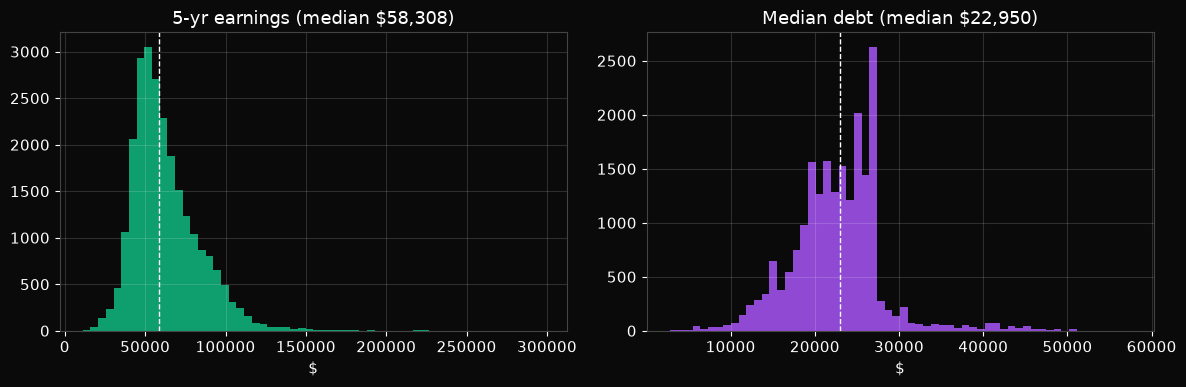

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(df['earn_5yr'].dropna(), bins=60, color=GREEN, alpha=0.85)
ax[0].axvline(df['earn_5yr'].median(), color='white', ls='--', lw=1)
ax[0].set_title(f"5-yr earnings (median ${df['earn_5yr'].median():,.0f})"); ax[0].set_xlabel('$')
ax[1].hist(df['debt'].dropna(), bins=60, color=PURPLE, alpha=0.85)
ax[1].axvline(df['debt'].median(), color='white', ls='--', lw=1)
ax[1].set_title(f"Median debt (median ${df['debt'].median():,.0f})"); ax[1].set_xlabel('$')
plt.tight_layout(); plt.show()

## The payoff metric

`years_to_payoff` is a deliberately **transparent simplification**: it assumes a borrower puts **10% of earnings** toward debt each year.

$$\text{years to pay off} = \frac{\text{median debt}}{0.10 \times \text{median 5-yr earnings}}$$

It ignores interest, taxes and living costs, so it *understates* real payoff time — it is a comparative lens, not a personal forecast. We recompute it to confirm it matches the published value.

In [5]:
chk = df.dropna(subset=['debt','payoff_yrs']).copy()
chk['recomputed'] = (chk['debt'] / (0.10 * chk['earn_5yr'])).round(1)
match = (chk['recomputed'] == chk['payoff_yrs']).mean()
print(f'recomputed payoff matches published for {match:.1%} of programs')
chk[['major','school','earn_5yr','debt','payoff_yrs','recomputed']].head()

recomputed payoff matches published for 100.0% of programs


,major,school,earn_5yr,debt,payoff_yrs,recomputed
0,"Agriculture, General",California Polytechnic State University-San Lu...,68350,21903.0,3.2,3.2
1,"Agriculture, General",California State University-Chico,64138,14750.0,2.3,2.3
2,"Agriculture, General",Delaware State University,47478,21500.0,4.5,4.5
3,"Agriculture, General",Florida Agricultural and Mechanical University,42263,14000.0,3.3,3.3
4,"Agriculture, General",Illinois State University,64041,15750.0,2.5,2.5


## Suppression is never faked

The Scorecard withholds (`PrivacySuppressed`) any cell built on too few students. We keep those as missing — never 0, never imputed. The counts:

In [6]:
q = load('quality.json')['programs']
print('Total field-of-study rows:', f"{q['fos_total_rows']:,}")
print('Kept (observed earnings):  ', f"{q['programs_kept']:,}")
print('Earnings-suppressed rows:  ', f"{q['earnings_suppressed_rows']:,}")
print('Dropped (no UNITID / closed schools):', q.get('dropped_no_unitid'))

Total field-of-study rows: 227,980
Kept (observed earnings):   62,406
Earnings-suppressed rows:   169,448
Dropped (no UNITID / closed schools): 1211


**Takeaway.** A clean, program-level ROI picture built only from observed federal data. Next: [notebook 2](02_jobs_ai_premium.ipynb) — where each degree leads, and how exposed those jobs are to AI.